In [1]:
from datetime import date, timedelta
from feed import get_data


symbol = "BTCUSDT"
days_of_data = 3

end_date = date.today()
start_date = end_date - timedelta(days=days_of_data)

start_date = int(start_date.strftime("%Y%m%d"))
end_date = int(end_date.strftime("%Y%m%d"))


dataset = get_data(
    symbol,
    start_date,
    end_date
)

dataset

,symbol,date,time,open,high,low,close,volume
0,BTCUSDT,20260918,0,76417.01,76427.60,76406.89,76406.90,5.04820
1,BTCUSDT,20260918,60,76406.89,76406.90,76396.08,76402.53,6.45478
2,BTCUSDT,20260918,120,76402.53,76421.19,76402.52,76421.19,2.50879
3,BTCUSDT,20260918,180,76421.19,76440.01,76421.18,76440.01,2.93092
4,BTCUSDT,20260918,240,76440.01,76440.01,76426.05,76426.05,2.95171
...,...,...,...,...,...,...,...,...
4315,BTCUSDT,20260920,86100,81188.01,81195.21,81172.01,81182.01,6.73080
4316,BTCUSDT,20260920,86160,81182.01,81184.01,81182.00,81184.01,1.58352
4317,BTCUSDT,20260920,86220,81184.00,81184.01,81180.00,81180.01,0.65043
4318,BTCUSDT,20260920,86280,81180.01,81180.01,81164.00,81164.00,1.52365


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import utils

In [4]:
dataset["datetime"] = (
    pd.to_datetime(
        dataset["date"].astype(str),
        format="%Y%m%d"
    )
    + pd.to_timedelta(dataset["time"], unit="s")
)


dataset



,symbol,date,time,open,high,low,close,volume,datetime
0,BTCUSDT,20260918,0,76417.01,76427.60,76406.89,76406.90,5.04820,2026-09-18 00:00:00
1,BTCUSDT,20260918,60,76406.89,76406.90,76396.08,76402.53,6.45478,2026-09-18 00:01:00
2,BTCUSDT,20260918,120,76402.53,76421.19,76402.52,76421.19,2.50879,2026-09-18 00:02:00
3,BTCUSDT,20260918,180,76421.19,76440.01,76421.18,76440.01,2.93092,2026-09-18 00:03:00
4,BTCUSDT,20260918,240,76440.01,76440.01,76426.05,76426.05,2.95171,2026-09-18 00:04:00
...,...,...,...,...,...,...,...,...,...
4315,BTCUSDT,20260920,86100,81188.01,81195.21,81172.01,81182.01,6.73080,2026-09-20 23:55:00
4316,BTCUSDT,20260920,86160,81182.01,81184.01,81182.00,81184.01,1.58352,2026-09-20 23:56:00
4317,BTCUSDT,20260920,86220,81184.00,81184.01,81180.00,81180.01,0.65043,2026-09-20 23:57:00
4318,BTCUSDT,20260920,86280,81180.01,81180.01,81164.00,81164.00,1.52365,2026-09-20 23:58:00


In [5]:
import utils


window = 10
source = "close"

for i in range(window - 1, len(dataset)):

    prices = dataset[source].iloc[i-window+1:i+1].tolist()
    times = list(range(window))

    regression = utils.regression_line(prices, times)

    dataset.loc[i, "regression_m"] = regression.m
    dataset.loc[i, "regression_b"] = regression.b
    dataset.loc[i, "r_squared"] = regression.r_squared

dataset = dataset.dropna(subset=["regression_m", "regression_b", "r_squared"])

dataset

,symbol,date,time,open,high,low,close,volume,datetime,regression_m,regression_b,r_squared
9,BTCUSDT,20260918,540,76394.00,76440.01,76394.00,76440.01,5.91136,2026-09-18 00:09:00,-0.037758,76413.626909,0.000035
10,BTCUSDT,20260918,600,76440.01,76448.01,76438.19,76438.20,3.69651,2026-09-18 00:10:00,0.874727,76412.650727,0.016359
11,BTCUSDT,20260918,660,76438.19,76438.20,76412.00,76412.00,1.49146,2026-09-18 00:11:00,-0.312606,76418.940727,0.002195
12,BTCUSDT,20260918,720,76412.01,76412.01,76383.60,76383.61,2.43060,2026-09-18 00:12:00,-1.919273,76422.412727,0.065082
13,BTCUSDT,20260918,780,76383.60,76460.01,76383.60,76460.00,97.55941,2026-09-18 00:13:00,2.350970,76405.195636,0.075023
...,...,...,...,...,...,...,...,...,...,...,...,...
4315,BTCUSDT,20260920,86100,81188.01,81195.21,81172.01,81182.01,6.73080,2026-09-20 23:55:00,-4.215636,81251.158364,0.124914
4316,BTCUSDT,20260920,86160,81182.01,81184.01,81182.00,81184.01,1.58352,2026-09-20 23:56:00,-8.721394,81269.433273,0.474494
4317,BTCUSDT,20260920,86220,81184.00,81184.01,81180.00,81180.01,0.65043,2026-09-20 23:57:00,-12.404121,81282.406545,0.823625
4318,BTCUSDT,20260920,86280,81180.01,81180.01,81164.00,81164.00,1.52365,2026-09-20 23:58:00,-13.789212,81279.337455,0.894454


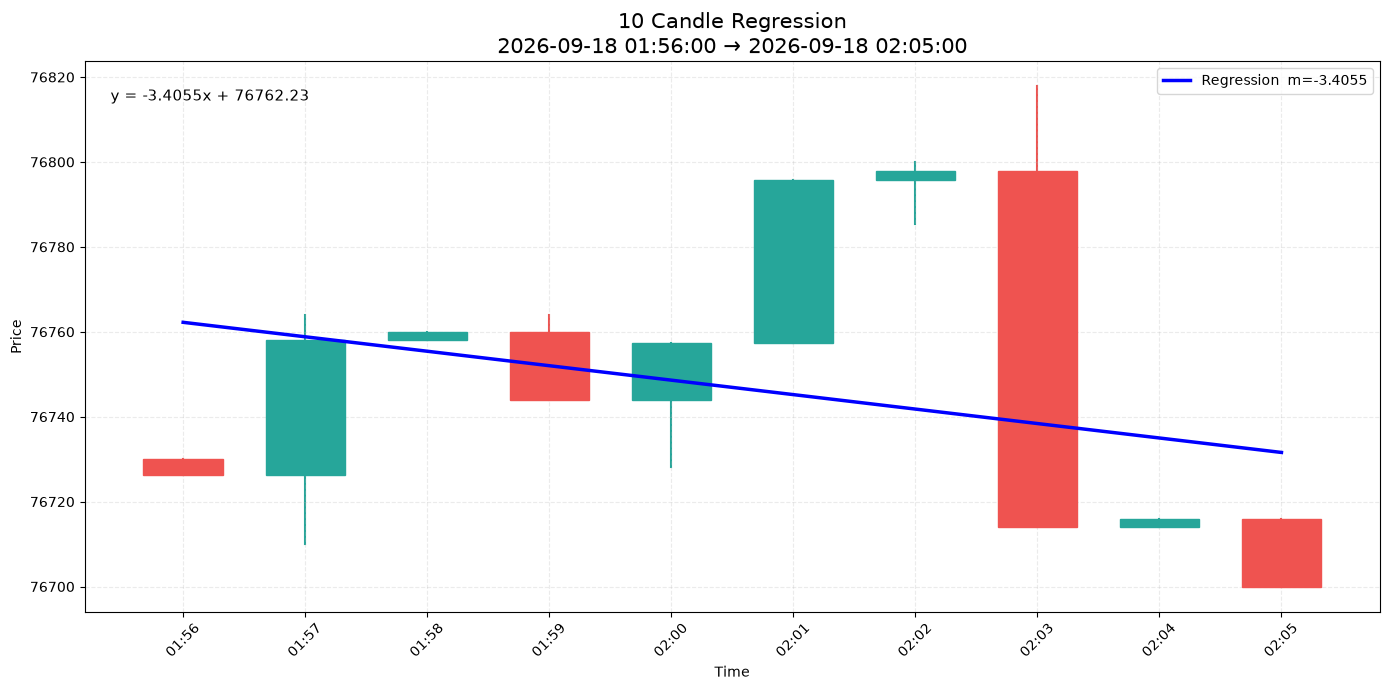

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def plot_regression_window(dataset, end_idx, window=10):

    start_idx = end_idx - window + 1
    data = dataset.iloc[start_idx:end_idx + 1].copy()

    # x positions: 0, 1, 2, ... 9
    x = np.arange(window)

    # --------------------------------------------------
    # Get regression values for THIS 10-candle window
    # --------------------------------------------------

    m = data["regression_m"].iloc[-1]
    b = data["regression_b"].iloc[-1]
    r_squared = data["r_squared"].iloc[-1]

    regression_y = m * x + b

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, ax = plt.subplots(figsize=(14, 7))

    candle_width = 0.65

    for i, (_, row) in enumerate(data.iterrows()):

        open_price = row["open"]
        high_price = row["high"]
        low_price = row["low"]
        close_price = row["close"]

        # ----------------------------------------------
        # Candle color
        # ----------------------------------------------

        if close_price >= open_price:
            candle_color = "#26a69a"   # green
        else:
            candle_color = "#ef5350"   # red

        # ----------------------------------------------
        # Wick
        # ----------------------------------------------

        ax.plot(
            [i, i],
            [low_price, high_price],
            color=candle_color,
            linewidth=1.5,
            zorder=1
        )

        # ----------------------------------------------
        # Candle body
        # ----------------------------------------------

        body_low = min(open_price, close_price)
        body_high = max(open_price, close_price)
        body_height = body_high - body_low

        # Do not make doji candles invisible
        if body_height == 0:
            body_height = 0.1

        candle = Rectangle(
            (
                i - candle_width / 2,
                body_low
            ),
            candle_width,
            body_height,
            facecolor=candle_color,
            edgecolor=candle_color,
            linewidth=1,
            zorder=2
        )

        ax.add_patch(candle)

    # --------------------------------------------------
    # Regression line
    # --------------------------------------------------

    ax.plot(
        x,
        regression_y,
        color="blue",
        linewidth=2.5,
        label=f"Regression  m={m:.4f}",
        zorder=3
    )

    # --------------------------------------------------
    # X axis
    # --------------------------------------------------

    ax.set_xticks(x)

    ax.set_xticklabels(
        data["datetime"].dt.strftime("%H:%M"),
        rotation=45
    )

    # --------------------------------------------------
    # Labels
    # --------------------------------------------------

    ax.set_title(
        f"10 Candle Regression\n"
        f"{data['datetime'].iloc[0]} → "
        f"{data['datetime'].iloc[-1]}",
        fontsize=15
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Price")

    # --------------------------------------------------
    # Grid
    # --------------------------------------------------

    ax.grid(
        True,
        alpha=0.25,
        linestyle="--"
    )

    # --------------------------------------------------
    # Regression equation
    # --------------------------------------------------

    ax.text(
        0.02,
        0.95,
        f"y = {m:.4f}x + {b:.2f}",
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top"
    )

    ax.legend()

    plt.tight_layout()
    plt.show()



plot_regression_window(
    dataset,
    end_idx=116,
    window=10
)



#end_index observations 108 - 116 reverse trend



In [ ]:
for row in dataset.iterrows():
    next_return = row["regression_m"] * row[0] + row["regression_b"]

    